In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6582, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [28]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [29]:
load_path = '../../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

### Keep Copy of Model Layers 

In [34]:
import copy

In [35]:
original_layers = copy.deepcopy(model.bert.encoder.layer)

In [36]:
from train_eval_func import get_primary_metric, set_lr_scheduler
import os
from layer_merge_helper import merge_mha, merge_ff

In [37]:
from torch.optim import AdamW
from train_eval_func import train
import torch.nn as nn

In [38]:
from structure_prune_helper import compute_importance_scores

In [39]:
def layer_drop(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    init_metric,
    cka_evaluator=None,
    num_merges=6,
    target_layers=[3, 4, 5, 6, 7],
    recovery_epochs=10,
    recovery_lr=1e-5,
    patience=2,
    save_dir='./weights/',
    keep_temp_checkpoints=False,
    cka_max_iter=float("Inf"),
    teacher_model=None,
    alpha=0.5,
    temperature=6,
    drop_strategy="top"
):
    recovery_dir = save_dir
    save_dir = save_dir + drop_strategy+ "/"
    
    orig_n_layer = len(model.bert.encoder.layer)
    target_metric = get_primary_metric(task_name)
    threshold = init_metric[target_metric] * 0.01

    # Create recovery checkpoint directory
    recovery_dir = os.path.join(recovery_dir, 'recovery')
    os.makedirs(recovery_dir, exist_ok=True)
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"Target Metric for {task_name}: {target_metric}")
    print(f"Original {target_metric} score: {init_metric[target_metric]:.4f}")
    print(f"Recovery threshold: {threshold:.4f}")
    print("")

    performance_track = []
    remaining_layers = []
    layers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

    performance_track.append(init_metric)
    remaining_layers.append(layers)
    for merge_itr in range(num_merges):
        print("=" * 70)
        print(f"Merge Iteration: {merge_itr + 1}/{num_merges}")
        print("=" * 70)

        # Drop Layer
        if drop_strategy == "top":
            model.bert.encoder.layer = model.bert.encoder.layer[:-1]
            layers = layers[:-1]
        elif drop_strategy == "contribution":
            cls_reps_similarity = cka_eval.pairwise(
                model, 
                train_dataloader, 
                device, 
                only_cls_token=True, 
                max_iter=cka_max_iter
            )
            stats = cka_eval.similarity_stats(cls_reps_similarity)
            
            print("  Similarity Stats:")
            print(f"    Average: {stats['average']:.6f}")
            print(f"    Highest: {stats['max']:.6f}")
            print(f"    Lowest:  {stats['min']:.6f}")
        
            merge_layer = stats['argmax']
            print("Drop Layer:", merge_layer)
        
            model.bert.encoder.layer = nn.ModuleList(
                [layer for i, layer in enumerate(model.bert.encoder.layer) if i != merge_layer]
            )
            model.config.num_hidden_layers = len(model.bert.encoder.layer)

            layers.pop(merge_layer)
        elif drop_strategy == "contribution_merge":
            cls_reps_similarity = cka_eval.pairwise(
                model, 
                train_dataloader, 
                device, 
                only_cls_token=True, 
                max_iter=cka_max_iter
            )
            stats = cka_eval.similarity_stats(cls_reps_similarity)
            
            print("  Similarity Stats:")
            print(f"    Average: {stats['average']:.6f}")
            print(f"    Highest: {stats['max']:.6f}")
            print(f"    Lowest:  {stats['min']:.6f}")
        
            merge_layer = stats['argmax']
            print("Drop Layer:", merge_layer)

            head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

            head_imp1, indices1 = torch.sort(head_importance[merge_layer], descending=True)
            head_imp2, indices2 = torch.sort(head_importance[merge_layer+1], descending=True)
    
            neuron_imp1, indices1 = torch.sort(neuron_importance[merge_layer], descending=True)        
            neuron_imp2, indices1 = torch.sort(neuron_importance[merge_layer+1], descending=True)
            
            merge_mha(model, model.bert.encoder.layer[merge_layer], model.bert.encoder.layer[merge_layer+1], head_imp1, head_imp2, device, 4)
            merge_ff(model, model.bert.encoder.layer[merge_layer], model.bert.encoder.layer[merge_layer+1], neuron_imp1, neuron_imp2, device, extra_neurons=1024)
    
            del model.bert.encoder.layer[merge_layer]
            
        else:
            return "Specify drop strategy"

        print("Number of Layers Remaining:", len(model.bert.encoder.layer))

        # Post Drop Performance 
        eval_metric = eval_loop(model, val_dataloader, task_name, device)[0]
        
        print("  Metrics:")
        for metric_name, value in eval_metric.items():
            marker = "★" if metric_name == target_metric else " "
            print(f"    {marker} {metric_name}: {value:.4f}")
        
        # Recovery Training
        diff = init_metric[target_metric] - eval_metric[target_metric]
        print(f"  Performance drop: {diff:.4f} (threshold: {threshold:.4f})")

        is_retrained = False
        if diff > threshold:
            print("  → Recovery training NEEDED")

            # Setup optimizer and scheduler
            optimizer = AdamW(model.parameters(), lr=recovery_lr)
            num_training_steps = recovery_epochs * len(train_dataloader)
            lr_scheduler = set_lr_scheduler(
                optimizer=optimizer,
                num_training_steps=num_training_steps
            )
            
            print(f"  → Training: {recovery_epochs} epochs, lr={recovery_lr}")
            
            # Temporary checkpoint path
            temp_save_path = os.path.join(recovery_dir, f'temp_iter{merge_itr}.pt')
            
            # Train with checkpoint saving
            # lr_scheduler= None
            train_stats = train(
                model,
                train_dataloader,
                val_dataloader,
                task_name,
                device,
                num_epochs=recovery_epochs,
                lr=recovery_lr,
                patience=patience,
                use_early_stopping=True,
                optimizer=optimizer,
                lr_scheduler=lr_scheduler,
                save_path=temp_save_path,
                display_epoch_iter=True,
                teacher_model=teacher_model, alpha=alpha, temperature=temperature
            )

             # CRITICAL: Reload best checkpoint
            print("\n  → Loading best checkpoint...")
            best_checkpoint = torch.load(temp_save_path)
            model.load_state_dict(best_checkpoint['model_state_dict'])
            
            print(f"  ✓ Loaded best checkpoint from epoch {best_checkpoint['epoch']}")
            print(f"    Best val loss: {best_checkpoint['val_loss']:.4f}")
            print(f"    Best val metrics: {best_checkpoint['val_metrics']}")
            
            # merge_history['metrics_after_recovery'].append(best_checkpoint['val_metrics'])
            # merge_history['training_stats'].append(train_stats)
            
            # Clean up temp checkpoint if not keeping
            if not keep_temp_checkpoints:
                os.remove(temp_save_path)
                print(f"  ✓ Cleaned up temporary checkpoint")

            is_retrained = True
        else:
            print("  → Recovery training NOT needed")

        eval_metric = eval_loop(model, val_dataloader, task_name, device)[0]
        performance_track.append(eval_metric)
        remaining_layers.append(layers.copy())
        
        n_layer = orig_n_layer - merge_itr - 1
        if n_layer in target_layers:
            save_path = os.path.join(save_dir, f'layer-{n_layer}-{task_name}.pt')
            
            save_object = {
                'model_state_dict': model.state_dict(),
                # 'layer_track': tracker.get_mapping(),
                # 'train_stats': merge_history['training_stats'][-1],
                # 'metrics_after_merge': merge_history['metrics_after_merge'][-1],
                # 'metrics_after_recovery': merge_history['metrics_after_recovery'][-1],
                'merge_iteration': merge_itr + 1,
                'num_layers': n_layer,
                'is_retrained': is_retrained
            }
            
            torch.save(save_object, save_path)
            print(f"  ✓ Saved {n_layer}-layer model to {save_path}")
        else:
            print(f"  • {n_layer} layers (not in target list, skipping save)")
        
        ## Store iteration info
        # merge_history['iterations'].append({
        #     'iteration': merge_itr + 1,
        #     'merged_layers': (merge_layer, merge_layer + 1),
        #     'num_layers_after': n_layer
        # })
        # merge_history['layer_compositions'].append(tracker.get_mapping())

    return_obj = {
        "performance_track": performance_track,
        "remaining_layers": remaining_layers
    }

    return return_obj

In [40]:
init_metric = eval_loop(model, val_dataloader, task_name, device)[0]
init_metric

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [38]:
performance_top_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9, 
    teacher_model=teacher_model, drop_strategy="top"
)

Target Metric for mrpc: f1
Original f1 score: 0.9094
Recovery threshold: 0.0091

Merge Iteration: 1/9
Number of Layers Remaining: 11
  Metrics:
      accuracy: 0.8799
    ★ f1: 0.9171
  Performance drop: -0.0077 (threshold: 0.0091)
  → Recovery training NOT needed
  • 11 layers (not in target list, skipping save)
Merge Iteration: 2/9
Number of Layers Remaining: 10
  Metrics:
      accuracy: 0.8725
    ★ f1: 0.9100
  Performance drop: -0.0006 (threshold: 0.0091)
  → Recovery training NOT needed
  • 10 layers (not in target list, skipping save)
Merge Iteration: 3/9
Number of Layers Remaining: 9
  Metrics:
      accuracy: 0.7892
    ★ f1: 0.8259
  Performance drop: 0.0835 (threshold: 0.0091)
  → Recovery training NEEDED
  → Training: 10 epochs, lr=1e-05


Training:   0%|          | 0/1150 [00:00<?, ?it/s]

Knowledge distillation used!


/home/abhinavl/work/Layer_Graft/layer-grafting-publication/drop_layer_strategy/top_drop/../../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|▉         | 114/1150 [00:19<02:12,  7.81it/s]

✓ Saved checkpoint (best loss: 0.9333)

<----------------- Epoch 1 ----------------->
Loss: 0.37, Training Metrics:
  accuracy: 0.9746
  f1: 0.9813
Validation Loss: 0.93, Validation Metrics:
  accuracy: 0.8652
  f1: 0.9076
Elapsed Time: 20.4511 sec


...

Training:  30%|███       | 345/1150 [00:45<01:42,  7.86it/s]


<----------------- Epoch 3 ----------------->
Loss: 1.26, Training Metrics:
  accuracy: 0.8735
  f1: 0.9107
Validation Loss: 1.33, Validation Metrics:
  accuracy: 0.7402
  f1: 0.8285
Elapsed Time: 13.7072 sec


Training:  40%|████      | 460/1150 [01:00<01:30,  7.61it/s]


<----------------- Epoch 4 ----------------->
Loss: 0.87, Training Metrics:
  accuracy: 0.9171
  f1: 0.9401
Validation Loss: 1.49, Validation Metrics:
  accuracy: 0.7255
  f1: 0.8217
Elapsed Time: 13.5235 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 60.34 sec
Chosen Primary Metric: f1
Best Metric Run: 0.8328

  → Loading best checkpoint...
  ✓ Loaded best checkpoint from epoch 2
    Best val loss: 1.2039
    Best val metrics: {'accuracy': 0.7352941176470589, 'f1': 0.8328173374613003}


  ✓ Cleaned up temporary checkpoint
  ✓ Saved 3-layer model to ./weights/top/layer-3-mrpc.pt


In [ ]:
performance_top_track

In [40]:
torch.save(performance_top_track, f'./weights/top/performance_track_{task_name}.pt')

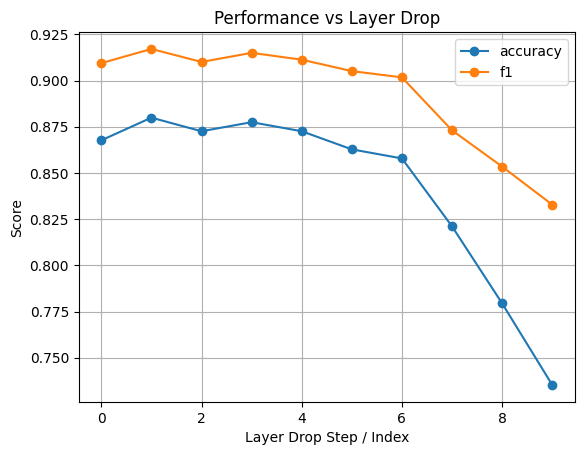

In [47]:
import matplotlib.pyplot as plt

performance_track = performance_top_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()

In [40]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [41]:
performance_contribution_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="contribution"
)

Target Metric for mrpc: f1
Original f1 score: 0.9094
Recovery threshold: 0.0091

Merge Iteration: 1/9


CKA Evaluation: 100%|██████████| 115/115 [00:07<00:00, 14.47it/s]


  Similarity Stats:
    Average: 0.899861
    Highest: 0.993713
    Lowest:  0.724249
Drop Layer: 9
Number of Layers Remaining: 11
  Metrics:
      accuracy: 0.8799
    ★ f1: 0.9142
  Performance drop: -0.0048 (threshold: 0.0091)
  → Recovery training NOT needed
  • 11 layers (not in target list, skipping save)
Merge Iteration: 2/9


CKA Evaluation: 100%|██████████| 115/115 [00:06<00:00, 16.77it/s]


  Similarity Stats:
    Average: 0.890264
    Highest: 0.987638
    Lowest:  0.725437
Drop Layer: 8
Number of Layers Remaining: 10
  Metrics:
      accuracy: 0.7574
    ★ f1: 0.7925
  Performance drop: 0.1169 (threshold: 0.0091)
  → Recovery training NEEDED
  → Training: 10 epochs, lr=1e-05


...

Training:  40%|███▉      | 459/1150 [00:44<00:43, 15.81it/s]


<----------------- Epoch 4 ----------------->
Loss: 1.11, Training Metrics:
  accuracy: 0.8858
  f1: 0.9182
Validation Loss: 1.66, Validation Metrics:
  accuracy: 0.6985
  f1: 0.7974
Elapsed Time: 8.959 sec


Training:  50%|█████     | 575/1150 [00:54<00:54, 10.49it/s]


<----------------- Epoch 5 ----------------->
Loss: 0.9, Training Metrics:
  accuracy: 0.9114
  f1: 0.9360
Validation Loss: 1.88, Validation Metrics:
  accuracy: 0.6814
  f1: 0.7890
Elapsed Time: 8.9185 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 54.76 sec
Chosen Primary Metric: f1
Best Metric Run: 0.7981

  → Loading best checkpoint...
  ✓ Loaded best checkpoint from epoch 3
    Best val loss: 1.6851
    Best val metrics: {'accuracy': 0.6911764705882353, 'f1': 0.7980769230769231}
  ✓ Cleaned up temporary checkpoint


  ✓ Saved 3-layer model to ./weights/contribution/layer-3-mrpc.pt


In [42]:
performance_contribution_track

{'performance_track': [{'accuracy': 0.8676470588235294,
   'f1': 0.9093959731543624},
  {'accuracy': 0.8799019607843137, 'f1': 0.9141856392294221},
  {'accuracy': 0.8700980392156863, 'f1': 0.9100169779286927},
  {'accuracy': 0.8578431372549019, 'f1': 0.8996539792387543},
  {'accuracy': 0.8504901960784313, 'f1': 0.8981636060100167},
  {'accuracy': 0.8651960784313726, 'f1': 0.905982905982906},
  {'accuracy': 0.8088235294117647, 'f1': 0.8733766233766234},
  {'accuracy': 0.7794117647058824, 'f1': 0.8514851485148515},
  {'accuracy': 0.6862745098039216, 'f1': 0.7968253968253968},
  {'accuracy': 0.6911764705882353, 'f1': 0.7980769230769231}],
 'remaining_layers': [[0, 6, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 10, 11],
  [0, 2, 3, 4, 5, 6, 7, 10, 11],
  [0, 2, 3, 4, 5, 6, 10, 11],
  [0, 2, 3, 4, 5, 6, 11],
  [0, 3, 4, 5, 6, 11],
  [0, 4, 5, 6, 11],
  [0, 5, 6, 11],
  [0, 6, 11]]}

In [43]:
torch.save(performance_contribution_track, f'./weights/top/performance_track_{task_name}.pt')

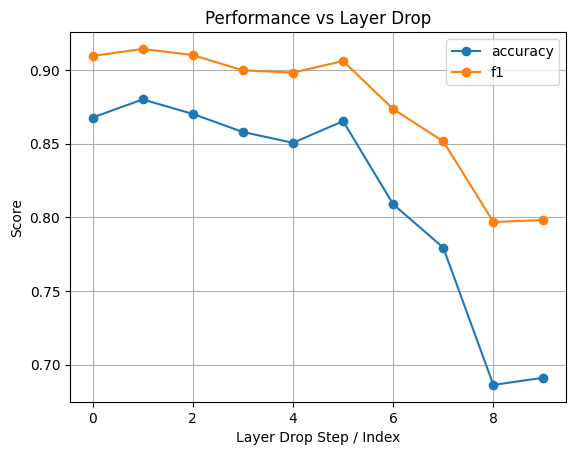

In [44]:
import matplotlib.pyplot as plt

performance_track = performance_contribution_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()

In [43]:
from layer_merge_helper import reorder_merged_layer_heads, reorder_merged_layer_neurons

In [44]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [45]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [46]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [47]:
performance_contribution_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="contribution_merge"
)

Target Metric for mrpc: f1
Original f1 score: 0.9094
Recovery threshold: 0.0091

Merge Iteration: 1/9


CKA Evaluation: 100%|██████████| 115/115 [00:08<00:00, 14.32it/s]


  Similarity Stats:
    Average: 0.899457
    Highest: 0.993674
    Lowest:  0.724031
Drop Layer: 9


Computing importance (heads + FFN): 100%|██████████| 115/115 [00:11<00:00, 10.00it/s]


9 7
2400 1696
Number of Layers Remaining: 11
  Metrics:
      accuracy: 0.8775
    ★ f1: 0.9141
  Performance drop: -0.0047 (threshold: 0.0091)
  → Recovery training NOT needed
  • 11 layers (not in target list, skipping save)
Merge Iteration: 2/9


...

Training:  20%|██        | 230/1150 [00:46<02:15,  6.77it/s]


<----------------- Epoch 2 ----------------->
Loss: 2.22, Training Metrics:
  accuracy: 0.7465
  f1: 0.8311
Validation Loss: 1.05, Validation Metrics:
  accuracy: 0.6789
  f1: 0.7820
Elapsed Time: 20.4461 sec


Training:  30%|███       | 345/1150 [01:07<02:38,  5.07it/s]


<----------------- Epoch 3 ----------------->
Loss: 1.92, Training Metrics:
  accuracy: 0.7882
  f1: 0.8521
Validation Loss: 1.26, Validation Metrics:
  accuracy: 0.6863
  f1: 0.7881
Elapsed Time: 20.1903 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 67.93 sec
Chosen Primary Metric: f1
Best Metric Run: 0.7928

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 1
    Best val loss: 0.8513
    Best val metrics: {'accuracy': 0.6911764705882353, 'f1': 0.7927631578947368}
  ✓ Cleaned up temporary checkpoint
  ✓ Saved 3-layer model to ./weights/contribution_merge/layer-3-mrpc.pt


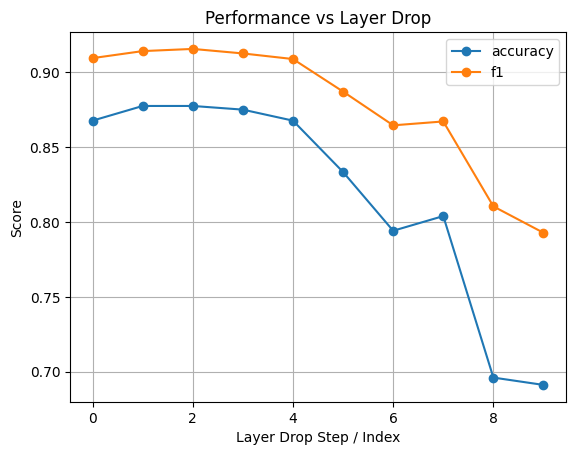

In [48]:
import matplotlib.pyplot as plt

performance_track = performance_contribution_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()